# Credit Default Risk Modeling - Exploratory Data Analysis (EDA)

**Objective**:
- Inspect data quality, missing values, and distributions.
- Eliminate **Data Leakage** (e.g., `FPD10+`, post-disbursement delinquency metrics) and uninformative **PII Identifiers** (e.g., `customer_id`).
- Analyze default rate (**Bad Rate %**) across primary target `DPD10_3MOB` (Days Past Due >= 10 in 3 Months on Book).
- Evaluate risk patterns across **Demographics (Age, Income, Gender, Occupation)**, geographic regions (`province`), device OS (`operating_system`), loan terms, and extracted **CIC Bureau features**.

In [1]:
# ==============================================================================
# 1. Environment & Library Setup
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from IPython.display import display

# Suppress non-critical warnings
warnings.filterwarnings("ignore")

# Color palettes for risk visualizations
# - Blue/Navy: Application Volume / Non-default population
# - Red/Coral: Bad Rate / High Default Risk
PRIMARY_COLOR = "#2b5c8f"  # Navy Blue (Volume / Safe)
RISK_COLOR = "#e74c3c"     # Coral Red (Default / High Risk)
PALETTE_BINARY = ["#2b5c8f", "#e74c3c"]
PALETTE_RISK_BARS = ["#ff7675", "#e74c3c", "#d63031", "#c0392b"]

In [2]:
# ==============================================================================
# 2. Load Extracted Dataset
# ==============================================================================
print("=" * 15, "DATASET OVERVIEW" ,"=" * 15)
data_path = "../data/processed/data_extracted.parquet"

if not os.path.exists(data_path):
    # Fallback to local working directory path if running from root
    data_path = "data/processed/data_extracted.parquet"

df = pd.read_parquet(data_path)
memory_usage = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory usage: {memory_usage:.2f} MB")
print(f"Duplicated rows: {df.duplicated().sum()}")

# Data types
print("\nData types of columns:")
print(df.dtypes.value_counts())

# Display full of column names
print("\nTotal number of columns:", len(df.columns))
cols_str = ", ".join(f'"{c}"' for c in df.columns)
df_wrapped = textwrap.fill(cols_str, width=220)
print(f"Column names: [{df_wrapped}]")

# Processing data for the "gender" feature
df['gender'] = df['gender'].replace({
    'Nam': 'MALE',
    'nam': 'MALE',
    'Nữ': 'FEMALE',
    'nu': 'FEMALE'
})

print(f"\nLoaded dataset successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(5)

=============== DATASET OVERVIEW ===============
Memory usage: 12.91 MB
Duplicated rows: 0

Data types of columns:
int64             72
float64           10
object             5
datetime64[ns]     1
Name: count, dtype: int64

Total number of columns: 88
Column names: ["disbursement_date", "Age", "gender", "occupation", "month_incom", "operating_system", "DPD10_3MOB", "SHORT_TERM_AMOUNT", "MID_TERM_AMOUNT", "LONG_TERM_AMOUNT", "SHORT_TERM_COUNT", "MID_TERM_COUNT", "LONG_TERM_COUNT",
"SHORT_TERM_COUNT_BANK", "MID_TERM_COUNT_BANK", "LONG_TERM_COUNT_BANK", "SHORT_TERM_COUNT_NON_BANK", "MID_TERM_COUNT_NON_BANK", "LONG_TERM_COUNT_NON_BANK", "NUM_LOANS", "NUM_LOANS_BANK", "NUM_LOANS_NON_BANK", "NUM_CC",
"NUM_CC_BANK", "NUM_CC_NON_BANK", "NUM_RELATIONSHIP", "OUTS_BAL_LOAN_M1", "OUTS_BAL_CC_M1", "OUTS_BAL_ALL_M1", "OUTS_BAL_LOAN_M2", "OUTS_BAL_CC_M2", "OUTS_BAL_ALL_M2", "OUTS_BAL_LOAN_M3", "OUTS_BAL_CC_M3",
"OUTS_BAL_ALL_M3", "OUTS_BAL_LOAN_M4", "OUTS_BAL_CC_M4", "OUTS_BAL_ALL_M4", "OUTS_BAL_LO

,disbursement_date,Age,gender,occupation,month_incom,operating_system,DPD10_3MOB,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,...,cic_num_loans,cic_num_fin_loans,cic_has_fin_loan,cic_primary_inst_type,cic_cc_util,cic_inquiry_3m,cic_util_trend,cic_balance_trend,cic_fin_ratio,province
0,2024-04-08,21,MALE,WORKER,9000000.0,Unknown,1,0,13,0,...,1,1,1,Finance,0.954545,2,17.025503,30.0,1.000000,Saigon
1,2024-04-11,38,MALE,OTHER,15000000.0,iOS,0,4,585,0,...,4,0,0,None,NaN,0,NaN,NaN,NaN,Others
2,2024-04-08,36,FEMALE,EMPLOYEE,40000000.0,iOS,0,7,44,3787,...,4,1,1,Bank,0.866667,4,205.174588,272.0,0.011464,Saigon
3,2024-04-08,21,MALE,STUDENT,8000000.0,iOS,0,6,0,0,...,0,0,0,None,NaN,0,NaN,NaN,NaN,Others
4,2024-04-08,21,MALE,OTHER,7000000.0,Unknown,1,11,0,0,...,2,1,0,None,NaN,0,NaN,NaN,NaN,Others


In [3]:
# ==============================================================================
# 3. Audit & Drop Data Leakage & Identifier Features
# ==============================================================================
target_col = "DPD10_3MOB"

# Explicitly identify leakage (post-disbursement performance) and ID columns
leakage_keywords = ["fpd", "collection", "recovery", "writeoff", "chargeoff", "overdue_days"]
id_keywords = ["customer_id", "application_id", "contract_id", "cif", "id_number", "id_card", "phone_number", "email", "full_name"]

dropped_cols = []
for col in df.columns:
    if col == target_col:
        continue
    col_l = col.lower().strip()
    if any(k in col_l for k in leakage_keywords) or (("dpd" in col_l) and (col != target_col)):
        dropped_cols.append(col)
    elif any(k in col_l for k in id_keywords) or col_l in ["id", "cif_no", "cust_id", "app_id"]:
        dropped_cols.append(col)
    elif df[col].nunique(dropna=False) <= 1:  # Constant / Zero variance
        dropped_cols.append(col)

if dropped_cols:
    print(f"Dropped {len(dropped_cols)} leakage/identifier/constant columns:")
    for col in dropped_cols:
        print(f"  - {col}")
    df = df.drop(columns=dropped_cols)
else:
    print("No additional leakage or identifier columns found.")

print(f"\nRemaining clean features for EDA: {df.shape[1]} columns ({df.shape[0]:,} records)")

No additional leakage or identifier columns found.

Remaining clean features for EDA: 88 columns (14,000 records)


In [4]:
# ==============================================================================
# 4. Data Quality & Missing Value Assessment
# ==============================================================================
print("=" * 80)
print("                    DATA QUALITY & INTEGRITY AUDIT")
print("=" * 80)

# Configure pandas display for clean tabular output
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 1. Missing Value & Cardinality Summary Table
quality_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Missing Count": df.isnull().sum(),
    "Missing Rate (%)": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

missing_features = quality_df[quality_df["Missing Count"] > 0].sort_values("Missing Rate (%)", ascending=False)

print(f"\n[1] Features with Missing Values ({len(missing_features)}/{len(df.columns)} columns):")
if not missing_features.empty:
    print(missing_features.to_string())
else:
    print("   -> No missing values detected across all columns.")

# 2. Suspicious String & Placeholder Audit
print("\n[2] Suspicious String Placeholders Audit:")
placeholder_tokens = ["?", "unknown", "null", "none", "", "n/a", "na", "<na>", "nan"]
suspicious_found = False

for col in df.select_dtypes(include=["object", "string"]).columns:
    col_str = df[col].astype(str).str.strip().str.lower()
    token_counts = {}
    for tok in placeholder_tokens:
        count = (col_str == tok).sum()
        if count > 0:
            token_counts[tok] = count
    if token_counts:
        suspicious_found = True
        tokens_str = ", ".join([f"'{k}': {v:,} rows" for k, v in token_counts.items()])
        print(f"   - Column '{col:<25}': {tokens_str}")

if not suspicious_found:
    print("   -> No suspicious string placeholders detected.")

# 3. Overall Matrix Completeness
total_cells = df.size
total_missing_cells = df.isnull().sum().sum()
overall_missing_pct = (total_missing_cells / total_cells) * 100
completeness_pct = 100.0 - overall_missing_pct

print("\n[3] Overall Matrix Health:")
print(f"   - Total Data Cells   : {total_cells:,}")
print(f"   - Total Missing Cells: {total_missing_cells:,} ({overall_missing_pct:.2f}% of all cells)")
print(f"   - Matrix Completeness: {completeness_pct:.2f}%")
print("=" * 80)

                    DATA QUALITY & INTEGRITY AUDIT

[1] Features with Missing Values (10/88 columns):
                      Data Type  Non-Null Count  Missing Count  Missing Rate (%)  Unique Values
cic_cc_util             float64           10218           3782             27.01           2243
cic_util_trend          float64           10254           3746             26.76           8885
cic_balance_trend       float64           10254           3746             26.76            627
cic_primary_inst_type    object           10283           3717             26.55              3
cic_fin_ratio           float64           10283           3717             26.55           1762
gender                   object           13999              1              0.01              2
occupation               object           13999              1              0.01             14
month_incom             float64           13999              1              0.01            189
cic_credit_score        float64   

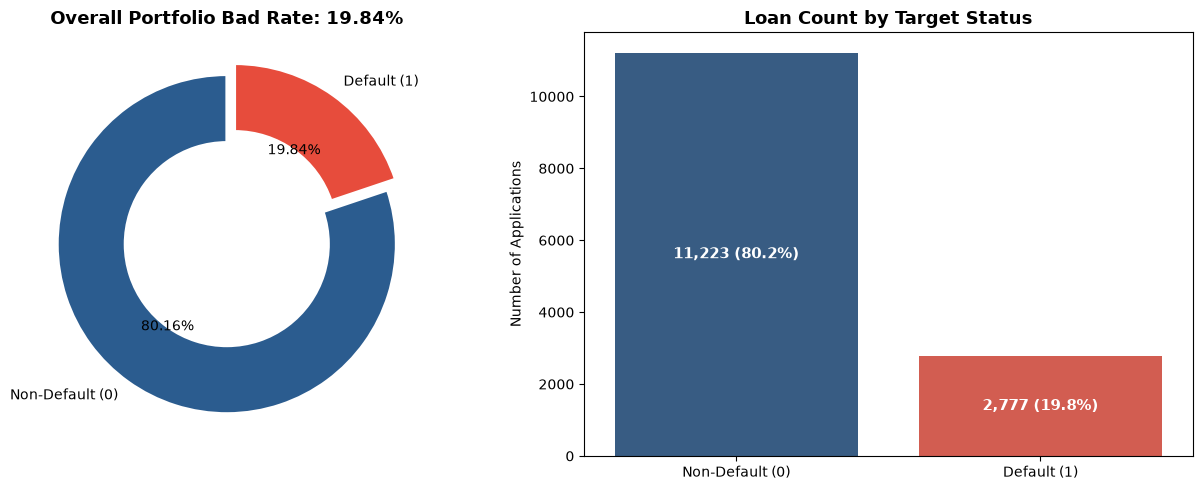

In [5]:
# ==============================================================================
# 5. Target Variable Analysis (DPD10_3MOB - Default / Bad Rate)
# ==============================================================================
if target_col in df.columns:
    target_counts = df[target_col].value_counts().sort_index()
    bad_rate = df[target_col].mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 1. Donut Chart
    labels = ["Non-Default (0)", "Default (1)"]
    axes[0].pie(
        target_counts,
        labels=labels,
        autopct="%1.2f%%",
        startangle=90,
        colors=PALETTE_BINARY,
        explode=(0, 0.08),
        wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2)
    )
    axes[0].set_title(f"Overall Portfolio Bad Rate: {bad_rate:.2f}%", fontsize=13, fontweight="bold")

    # 2. Count Bar Chart with exact volume labels
    sns.barplot(x=labels, y=target_counts.values, palette=PALETTE_BINARY, ax=axes[1])
    for p in axes[1].patches:
        height = int(p.get_height())
        axes[1].annotate(
            f"{height:,} ({height/len(df)*100:.1f}%)",
            (p.get_x() + p.get_width() / 2., p.get_height() / 2),
            ha="center", va="center", color="white", fontweight="bold", fontsize=11
        )
    axes[1].set_title("Loan Count by Target Status", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("Number of Applications", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print(f"Target column '{target_col}' not found in DataFrame.")

In [6]:
# ==============================================================================
# 6. Helper Function: Dual-Axis Bivariate Plot (Volume vs Bad Rate %)
# ==============================================================================
def plot_bivariate_dual_axis(data, col, target="DPD10_3MOB", title=None, min_count=10):
    """
    Creates a standard Risk Analytics dual-axis chart:
    - Bar (Left Axis): Application Volume (Navy Blue)
    - Line (Right Axis): Bad Rate % (Coral Red)
    """
    if col not in data.columns or target not in data.columns:
        return

    stats = data.groupby(col).agg(
        volume=(target, "count"),
        bad_rate=(target, "mean")
    ).reset_index()

    # Filter out categories with very few samples to prevent visual skew
    stats = stats[stats["volume"] >= min_count].copy()
    stats["bad_rate_pct"] = stats["bad_rate"] * 100
    stats = stats.sort_values("volume", ascending=False)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    # Left axis: Application Volume (Bar - Blue)
    sns.barplot(data=stats, x=col, y="volume", ax=ax1, color=PRIMARY_COLOR, alpha=0.85)
    ax1.set_ylabel("Application Volume (Count)", color=PRIMARY_COLOR, fontsize=10, fontweight="bold")
    ax1.grid(False)

    # Right axis: Bad Rate % (Line - Red)
    sns.lineplot(data=stats, x=col, y="bad_rate_pct", ax=ax2, color=RISK_COLOR, marker="o", linewidth=2.5, markersize=8)
    ax2.set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontsize=10, fontweight="bold")
    ax2.set_ylim(0, max(stats["bad_rate_pct"].max() * 1.3, 5))

    # Annotate Bad Rate % on markers
    for i, row in stats.reset_index().iterrows():
        ax2.annotate(
            f"{row['bad_rate_pct']:.1f}%",
            (i, row["bad_rate_pct"] + 0.4),
            ha="center", color=RISK_COLOR, fontweight="bold", fontsize=9
        )

    plt.title(title or f"Risk Analysis: {col} vs Bad Rate (%)", fontsize=13, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()

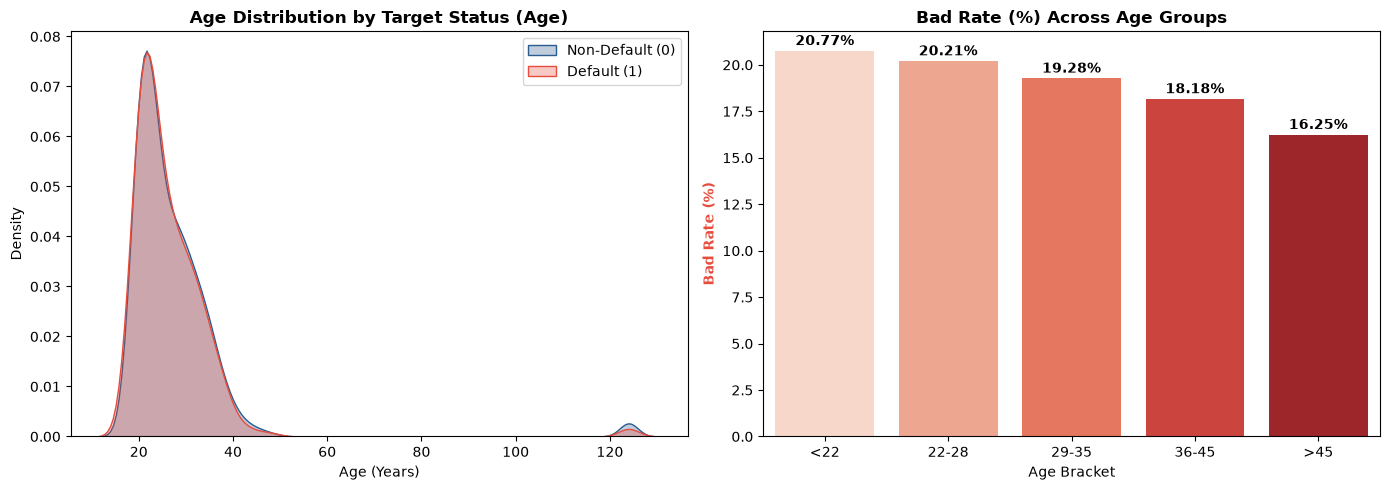

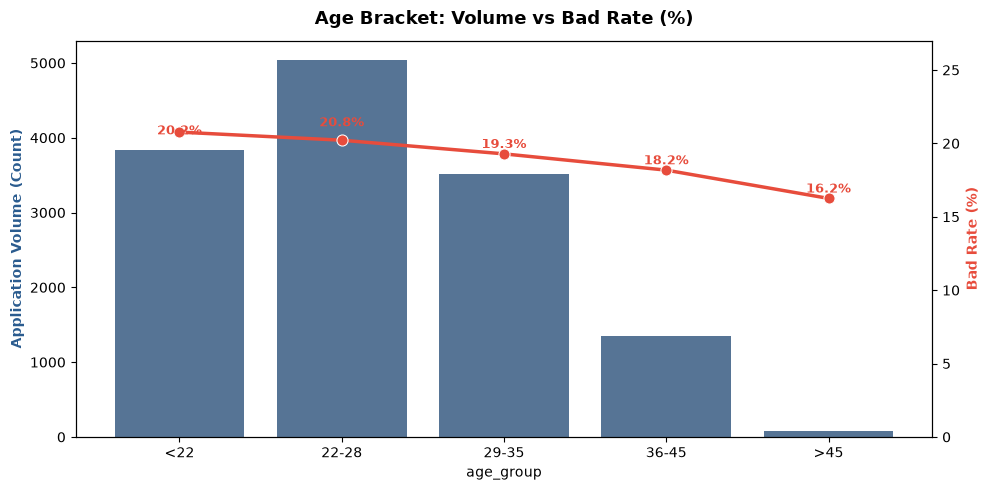

In [7]:
# ==============================================================================
# 7. Age & Demographics Risk Analysis
# ==============================================================================
age_col = next((c for c in df.columns if "age" in c.lower() or "tuoi" in c.lower()), None)

if age_col is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Continuous Age Distribution (KDE: Default vs Non-Default)
    sns.kdeplot(data=df[df[target_col] == 0][age_col].dropna(), label="Non-Default (0)", color=PRIMARY_COLOR, ax=axes[0], fill=True, alpha=0.3)
    sns.kdeplot(data=df[df[target_col] == 1][age_col].dropna(), label="Default (1)", color=RISK_COLOR, ax=axes[0], fill=True, alpha=0.3)
    axes[0].set_title(f"Age Distribution by Target Status ({age_col})", fontweight="bold")
    axes[0].set_xlabel("Age (Years)")
    axes[0].legend()

    # 2. Age Binning Groups vs Bad Rate (Red tones for risk)
    bins = [0, 22, 28, 35, 45, 100]
    labels = ["<22", "22-28", "29-35", "36-45", ">45"]
    df["age_group"] = pd.cut(df[age_col], bins=bins, labels=labels, right=False)

    age_stats = df.groupby("age_group")[target_col].agg(["count", "mean"]).reset_index()
    age_stats["bad_rate_pct"] = age_stats["mean"] * 100

    sns.barplot(data=age_stats, x="age_group", y="bad_rate_pct", palette="Reds", ax=axes[1])
    axes[1].set_title("Bad Rate (%) Across Age Groups", fontweight="bold")
    axes[1].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")
    axes[1].set_xlabel("Age Bracket")
    
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()
    
    # Dual-axis detailed plot for age_group
    plot_bivariate_dual_axis(df, "age_group", title="Age Bracket: Volume vs Bad Rate (%)")
else:
    print("Age column not detected in DataFrame.")

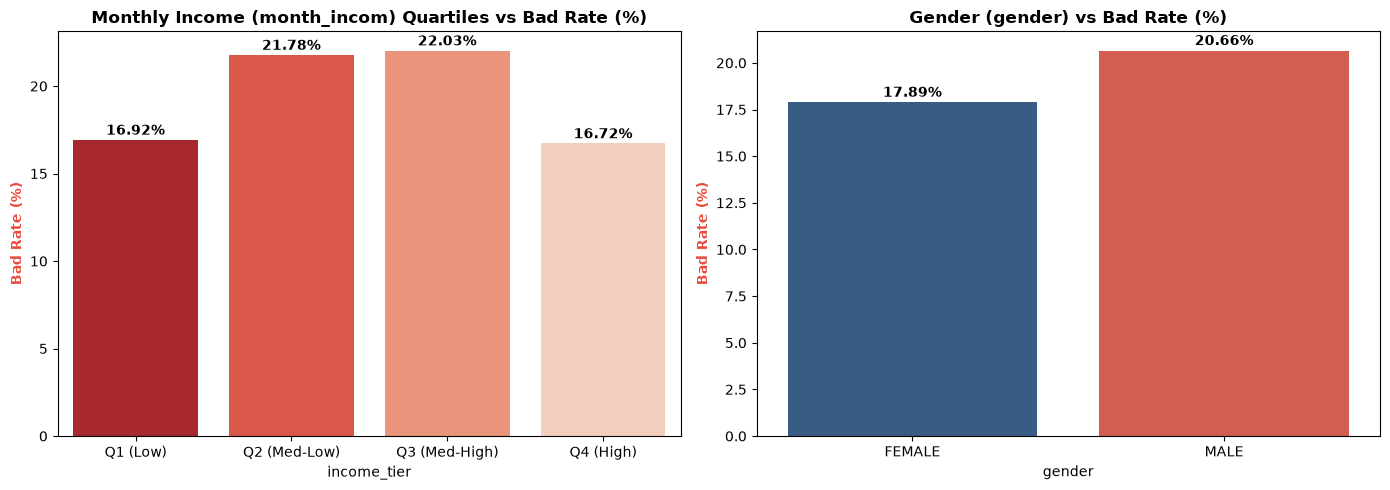

In [8]:
# ==============================================================================
# 8. Monthly Income, Gender & Existing Loans Risk Analysis
# ==============================================================================
income_col = next((c for c in df.columns if any(k in c.lower() for k in ["month_incom", "income", "thu_nhap"])), None)
gender_col = next((c for c in df.columns if "gender" in c.lower() or "gioi_tinh" in c.lower()), None)
num_loans_col = next((c for c in df.columns if c == "NUM_LOANS"), None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Monthly Income Quartiles vs Bad Rate (Red tones for risk)
if income_col is not None and df[income_col].notna().sum() > 0:
    df["income_tier"] = pd.qcut(df[income_col].dropna(), q=4, labels=["Q1 (Low)", "Q2 (Med-Low)", "Q3 (Med-High)", "Q4 (High)"])
    inc_stats = df.groupby("income_tier")[target_col].agg(["count", "mean"]).reset_index()
    inc_stats["bad_rate_pct"] = inc_stats["mean"] * 100
    sns.barplot(data=inc_stats, x="income_tier", y="bad_rate_pct", palette="Reds_r", ax=axes[0])
    axes[0].set_title(f"Monthly Income ({income_col}) Quartiles vs Bad Rate (%)", fontweight="bold")
    axes[0].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontweight="bold")
else:
    axes[0].text(0.5, 0.5, "Income column not found or all empty", ha="center", va="center")

# 2. Gender / Existing Loans vs Bad Rate (Red tones for risk)
if gender_col is not None:
    gen_stats = df.groupby(gender_col)[target_col].agg(["count", "mean"]).reset_index()
    gen_stats["bad_rate_pct"] = gen_stats["mean"] * 100
    sns.barplot(data=gen_stats, x=gender_col, y="bad_rate_pct", palette=PALETTE_BINARY, ax=axes[1])
    axes[1].set_title(f"Gender ({gender_col}) vs Bad Rate (%)", fontweight="bold")
    axes[1].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontweight="bold")
elif num_loans_col is not None:
    loan_stats = df.groupby(num_loans_col)[target_col].agg(["count", "mean"]).reset_index()
    loan_stats = loan_stats[loan_stats["count"] >= 20]
    sns.barplot(data=loan_stats, x=num_loans_col, y=loan_stats["mean"] * 100, palette="Reds", ax=axes[1])
    axes[1].set_title("Number of Existing Loans vs Bad Rate (%)", fontweight="bold")
    axes[1].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")

plt.tight_layout()
plt.show()

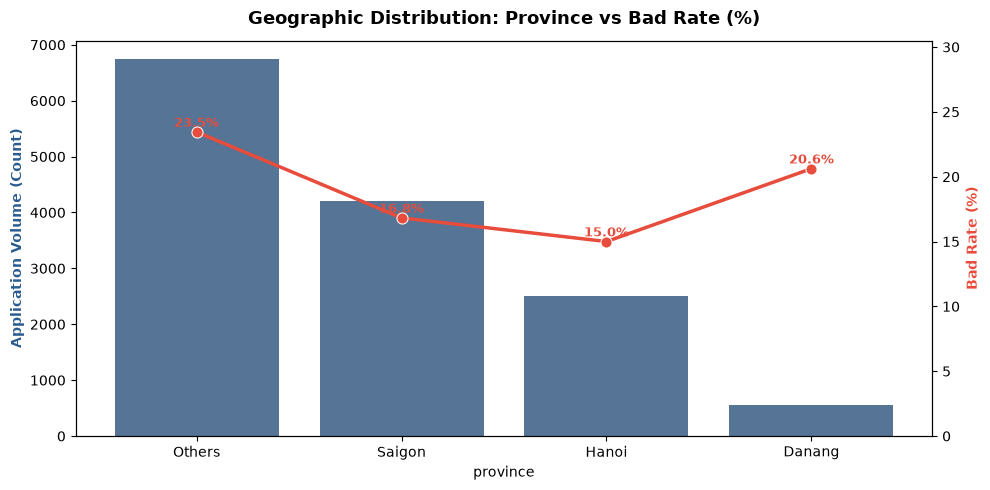

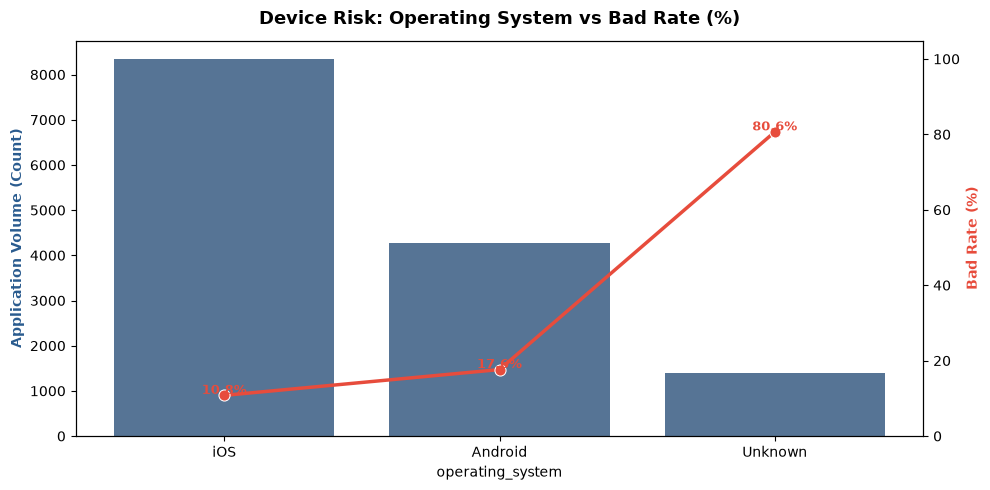

In [9]:
# ==============================================================================
# 9. Geographic & Device Analysis (Province & Operating System)
# ==============================================================================
# 1. Geographic Region (Hanoi, Danang, Saigon, Others)
if "province" in df.columns:
    plot_bivariate_dual_axis(df, "province", title="Geographic Distribution: Province vs Bad Rate (%)")

# 2. Operating System (iOS, Android, Unknown)
if "operating_system" in df.columns:
    plot_bivariate_dual_axis(df, "operating_system", title="Device Risk: Operating System vs Bad Rate (%)")

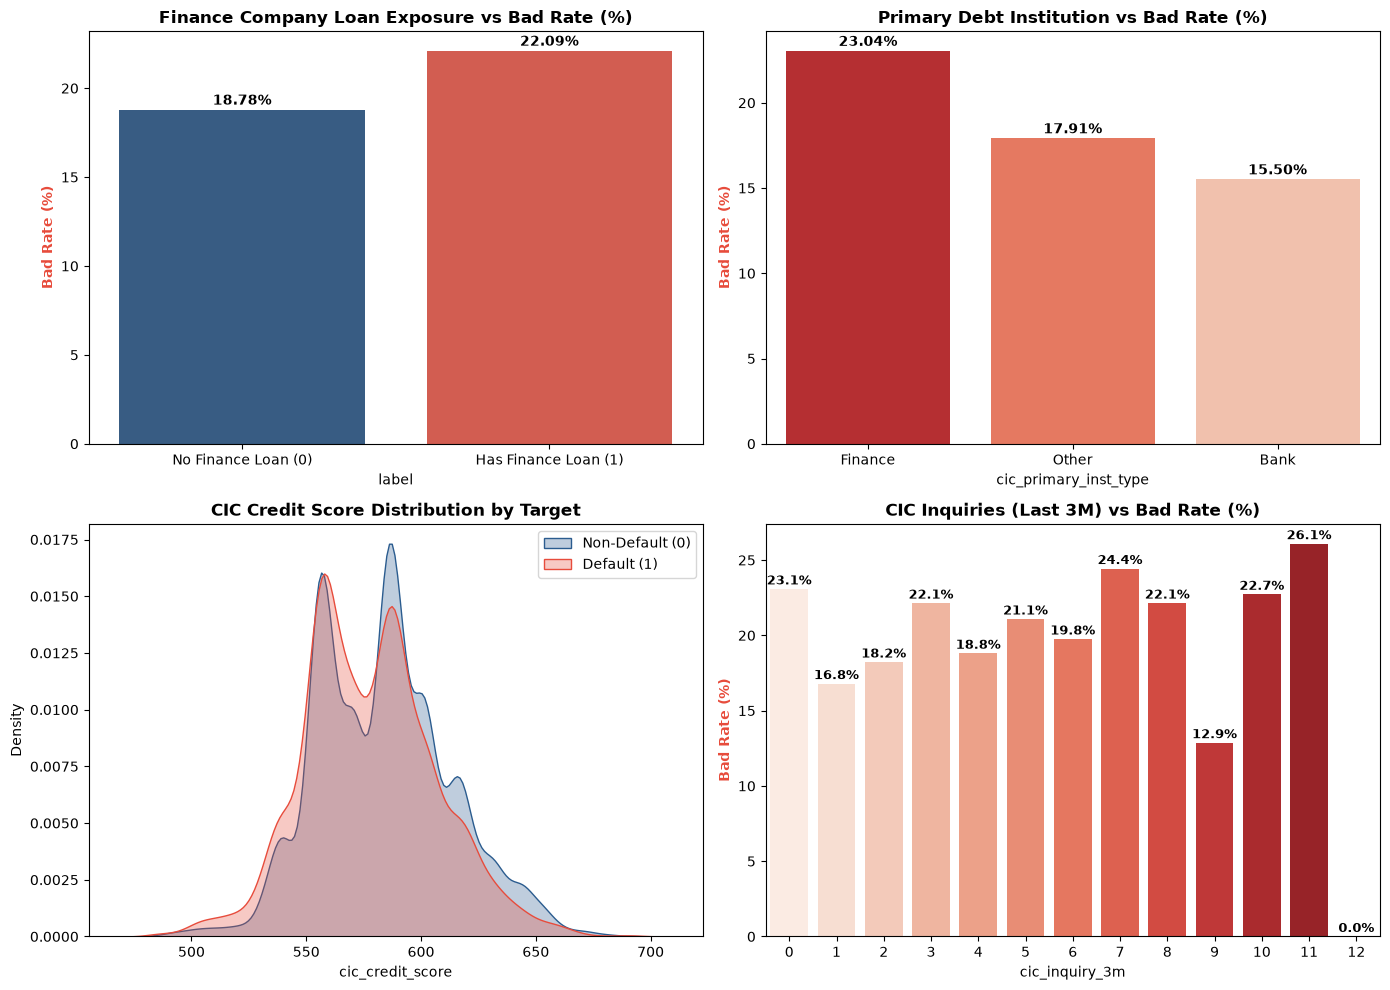

In [10]:
# ==============================================================================
# 10. CIC Credit Bureau Feature Analysis
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Has Finance Company Loan (cic_has_fin_loan)
if "cic_has_fin_loan" in df.columns:
    fin_stats = df.groupby("cic_has_fin_loan")[target_col].agg(["count", "mean"]).reset_index()
    fin_stats["label"] = fin_stats["cic_has_fin_loan"].map({0: "No Finance Loan (0)", 1: "Has Finance Loan (1)"})
    sns.barplot(data=fin_stats, x="label", y=fin_stats["mean"] * 100, ax=axes[0, 0], palette=PALETTE_BINARY)
    axes[0, 0].set_title("Finance Company Loan Exposure vs Bad Rate (%)", fontweight="bold")
    axes[0, 0].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")
    for p in axes[0, 0].patches:
        axes[0, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontweight="bold")

# 2. Primary Institution Type (cic_primary_inst_type)
if "cic_primary_inst_type" in df.columns:
    inst_stats = df.groupby("cic_primary_inst_type")[target_col].agg(["count", "mean"]).reset_index()
    inst_stats = inst_stats.sort_values("mean", ascending=False)
    sns.barplot(data=inst_stats, x="cic_primary_inst_type", y=inst_stats["mean"] * 100, ax=axes[0, 1], palette="Reds_r")
    axes[0, 1].set_title("Primary Debt Institution vs Bad Rate (%)", fontweight="bold")
    axes[0, 1].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")
    for p in axes[0, 1].patches:
        axes[0, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontweight="bold")

# 3. CIC Credit Score Distribution (Non-Default vs Default)
if "cic_credit_score" in df.columns:
    score_valid = df[df["cic_credit_score"].notna()]
    if not score_valid.empty:
        sns.kdeplot(data=score_valid[score_valid[target_col] == 0]["cic_credit_score"], label="Non-Default (0)", color=PRIMARY_COLOR, ax=axes[1, 0], fill=True, alpha=0.3)
        sns.kdeplot(data=score_valid[score_valid[target_col] == 1]["cic_credit_score"], label="Default (1)", color=RISK_COLOR, ax=axes[1, 0], fill=True, alpha=0.3)
        axes[1, 0].set_title("CIC Credit Score Distribution by Target", fontweight="bold")
        axes[1, 0].legend()

# 4. Recent Inquiries in Last 90 Days (cic_inquiry_3m)
if "cic_inquiry_3m" in df.columns:
    inq_stats = df.groupby("cic_inquiry_3m")[target_col].agg(["count", "mean"]).reset_index()
    inq_stats = inq_stats[inq_stats["count"] >= 20]
    sns.barplot(data=inq_stats, x="cic_inquiry_3m", y=inq_stats["mean"] * 100, ax=axes[1, 1], palette="Reds")
    axes[1, 1].set_title("CIC Inquiries (Last 3M) vs Bad Rate (%)", fontweight="bold")
    axes[1, 1].set_ylabel("Bad Rate (%)", color=RISK_COLOR, fontweight="bold")
    for p in axes[1, 1].patches:
        axes[1, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

1. TOP FEATURES CORRELATED WITH DEFAULT RISK (DPD10_3MOB)

[+] Top Positive Risk Drivers (Higher Value -> Higher Default Risk):
   01. cic_fin_ratio                       : +0.0894
   02. cic_num_fin_loans                   : +0.0696
   03. cic_fin_balance                     : +0.0655
   04. cic_balance_trend                   : +0.0544
   05. NUM_CC_NON_BANK                     : +0.0517
   06. cic_cc_util                         : +0.0512

[-] Top Negative Protective Drivers (Higher Value -> Lower Default Risk):
   01. OUTS_BAL_CC_M10                     : -0.0820
   02. NUM_CC                              : -0.0821
   03. OUTS_BAL_CC_M8                      : -0.0830
   04. OUTS_BAL_CC_M12                     : -0.0844
   05. OUTS_BAL_CC_M11                     : -0.0856
   06. NUM_CC_BANK                         : -0.1299

2. TOP 10 STRONGEST FEATURE-TO-FEATURE PAIRWISE CORRELATIONS (MULTICOLLINEARITY)


,Rank,Feature 1,Feature 2,Spearman r,Status
0,1,LONG_TERM_AMOUNT,LONG_TERM_COUNT,+0.9999,[!] High Collinearity
1,2,LONG_TERM_AMOUNT,LONG_TERM_COUNT_BANK,+0.9925,[!] High Collinearity
2,3,LONG_TERM_COUNT,LONG_TERM_COUNT_BANK,+0.9924,[!] High Collinearity
3,4,NUM_LOANS,cic_num_loans,+0.9794,[!] High Collinearity
4,5,OUTS_BAL_CC_M11,OUTS_BAL_CC_M12,+0.9775,[!] High Collinearity
5,6,OUTS_BAL_CC_M10,OUTS_BAL_CC_M11,+0.9772,[!] High Collinearity
6,7,OUTS_BAL_CC_M9,OUTS_BAL_CC_M10,+0.9771,[!] High Collinearity
7,8,OUTS_BAL_CC_M8,OUTS_BAL_CC_M9,+0.9755,[!] High Collinearity
8,9,OUTS_BAL_CC_M7,OUTS_BAL_CC_M8,+0.9750,[!] High Collinearity
9,10,OUTS_BAL_CC_M2,OUTS_BAL_CC_CURRENT,+0.9739,[!] High Collinearity


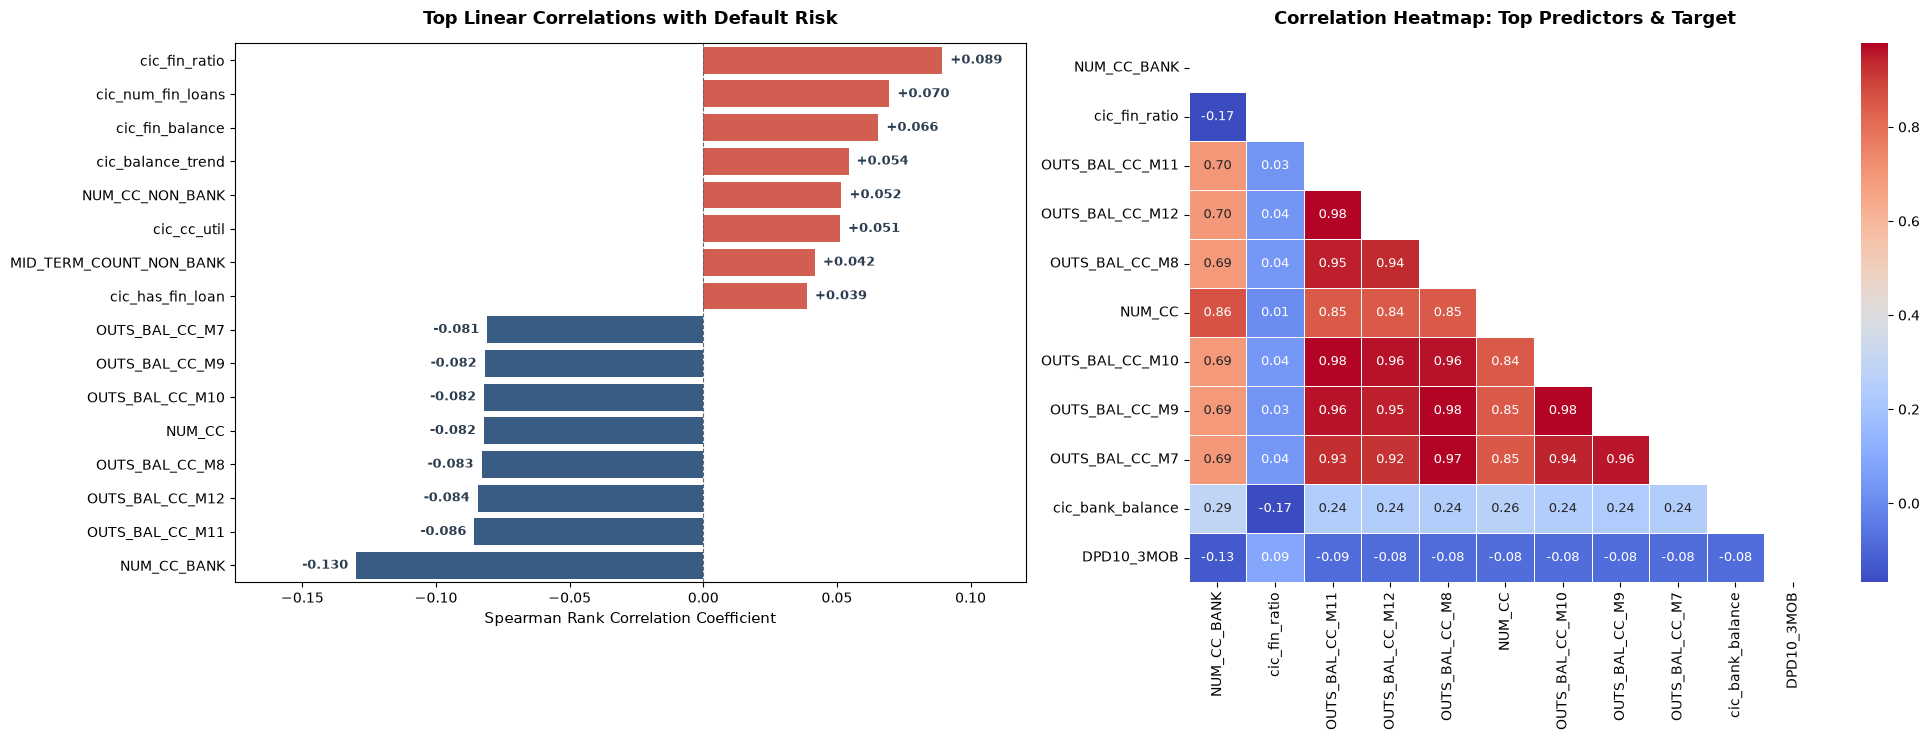

In [11]:
# ==============================================================================
# 11. Correlation Analysis, Top Risk Drivers & Feature Pairwise Collinearity
# ==============================================================================
numeric_df = df.select_dtypes(include=[np.number])
if target_col in numeric_df.columns:
    # --------------------------------------------------------------------------
    # 1. Target Correlation Analysis (Risk vs Protective Drivers)
    # --------------------------------------------------------------------------
    corr_target = numeric_df.corr(method="spearman")[target_col].drop(target_col).dropna().sort_values(ascending=False)

    print("=" * 80)
    print(f"1. TOP FEATURES CORRELATED WITH DEFAULT RISK ({target_col})")
    print("=" * 80)
    
    top_pos = corr_target.head(6)
    top_neg = corr_target.tail(6)
    
    print("\n[+] Top Positive Risk Drivers (Higher Value -> Higher Default Risk):")
    for i, (feat, val) in enumerate(top_pos.items(), 1):
        print(f"   {i:02d}. {feat:<35} : +{val:.4f}")
        
    print("\n[-] Top Negative Protective Drivers (Higher Value -> Lower Default Risk):")
    for i, (feat, val) in enumerate(top_neg.items(), 1):
        print(f"   {i:02d}. {feat:<35} : {val:.4f}")
    print("=" * 80 + "\n")

    # --------------------------------------------------------------------------
    # 2. Feature-to-Feature Pairwise Collinearity Screening (Top 10 Strongest Pairs)
    # --------------------------------------------------------------------------
    features_df = numeric_df.drop(columns=[target_col], errors="ignore")
    corr_matrix_full = features_df.corr(method="spearman")
    
    # Extract upper triangle without diagonal to avoid self-correlation and duplicate pairs
    upper_tri = corr_matrix_full.abs().where(np.triu(np.ones(corr_matrix_full.shape), k=1).astype(bool))
    paired_series = upper_tri.unstack().dropna().sort_values(ascending=False).head(10)
    
    # Construct a structured DataFrame for clean, non-truncated display
    collinearity_records = []
    for rank, ((feat2, feat1), abs_r) in enumerate(paired_series.items(), 1):
        actual_r = corr_matrix_full.loc[feat1, feat2]
        status = "[!] High Collinearity" if abs_r >= 0.85 else ("[*] Moderate" if abs_r >= 0.70 else "[o] Mild")
        collinearity_records.append({
            "Rank": rank,
            "Feature 1": feat1,
            "Feature 2": feat2,
            "Spearman r": f"{actual_r:+.4f}",
            "Status": status
        })
        
    collinearity_table = pd.DataFrame(collinearity_records)
    
    print("=" * 80)
    print("2. TOP 10 STRONGEST FEATURE-TO-FEATURE PAIRWISE CORRELATIONS (MULTICOLLINEARITY)")
    print("=" * 80)
    
    # Render native interactive HTML table in Jupyter (never truncated by VS Code)
    display(collinearity_table)
    print("=" * 80 + "\n")

    # --------------------------------------------------------------------------
    # 3. Combined Visualizations (Side-by-Side: Bar Plot & Correlation Heatmap)
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))

    # --- Subplot 1: Bar Plot of Top Risk Feature Correlations ---
    top_risk_features = pd.concat([corr_target.head(8), corr_target.tail(8)]).drop_duplicates()
    colors = [RISK_COLOR if x > 0 else PRIMARY_COLOR for x in top_risk_features.values]
    
    sns.barplot(x=top_risk_features.values, y=top_risk_features.index, palette=colors, ax=axes[0])
    axes[0].set_title("Top Linear Correlations with Default Risk", fontsize=13, fontweight="bold", pad=14)
    axes[0].set_xlabel("Spearman Rank Correlation Coefficient", fontsize=11)
    axes[0].set_ylabel("")  # Clear redundant y-axis label
    axes[0].axvline(0, color="#666666", linestyle="--", linewidth=0.8)

    # Expand x-axis limits dynamically to ensure annotations never clip or overlap axis ticks
    min_val, max_val = top_risk_features.min(), top_risk_features.max()
    axes[0].set_xlim(min_val * 1.35 if min_val < 0 else -0.05, max_val * 1.35 if max_val > 0 else 0.05)

    for i, v in enumerate(top_risk_features.values):
        if v >= 0:
            axes[0].text(v + 0.003, i, f"+{v:.3f}", va="center", ha="left", fontsize=9, fontweight="bold", color="#2c3e50")
        else:
            axes[0].text(v - 0.003, i, f"{v:.3f}", va="center", ha="right", fontsize=9, fontweight="bold", color="#2c3e50")

    # --- Subplot 2: Triangular Correlation Heatmap of Top Predictors ---
    top_cols = corr_target.abs().sort_values(ascending=False).head(10).index.tolist() + [target_col]
    corr_matrix_top = numeric_df[top_cols].corr(method="spearman")
    mask = np.triu(np.ones_like(corr_matrix_top, dtype=bool))

    sns.heatmap(
        corr_matrix_top, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        cbar=True, 
        linewidths=0.5, 
        ax=axes[1],
        annot_kws={"size": 9}
    )
    axes[1].set_title("Correlation Heatmap: Top Predictors & Target", fontsize=13, fontweight="bold", pad=14)
    axes[1].tick_params(axis="x", rotation=90)
    axes[1].tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print(f"Target column '{target_col}' not found in numeric DataFrame.")

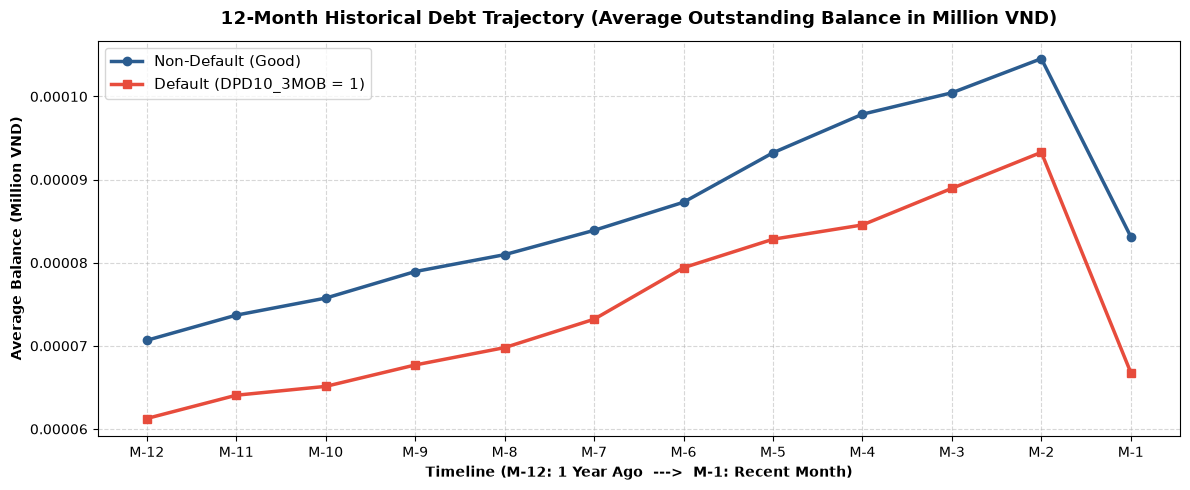

In [12]:
# ==============================================================================
# 12. Historical Debt Trajectory Analysis (12-Month Balance Trend)
# ==============================================================================
# Extract chronological 12-month total balance columns (M12 = 12 months ago -> M1 = 1 month ago)
balance_cols = [f"OUTS_BAL_ALL_M{i}" for i in range(12, 0, -1)]
available_m_cols = [col for col in balance_cols if col in df.columns]

if available_m_cols and target_col in df.columns:
    month_labels = [f"M-{i}" for i in range(12, 0, -1)]
    
    # Calculate average outstanding balance per month for Default vs Non-Default
    trend_non_default = df[df[target_col] == 0][available_m_cols].mean() / 1e6  # Scale to Millions VND
    trend_default = df[df[target_col] == 1][available_m_cols].mean() / 1e6

    plt.figure(figsize=(12, 5))
    
    # Plot non-default trajectory (Navy Blue)
    plt.plot(month_labels, trend_non_default.values, marker="o", linewidth=2.5, color=PRIMARY_COLOR, label="Non-Default (Good)")
    
    # Plot default trajectory (Coral Red)
    plt.plot(month_labels, trend_default.values, marker="s", linewidth=2.5, color=RISK_COLOR, label="Default (DPD10_3MOB = 1)")
    
    plt.title("12-Month Historical Debt Trajectory (Average Outstanding Balance in Million VND)", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("Timeline (M-12: 1 Year Ago  --->  M-1: Recent Month)", fontsize=10, fontweight="bold")
    plt.ylabel("Average Balance (Million VND)", fontsize=10, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(frameon=True, fontsize=11)
    
    # Annotate end points
    plt.annotate(f"{trend_non_default.iloc[-1]:.1f}M", (11, trend_non_default.iloc[-1] + 0.3), ha="center", color=PRIMARY_COLOR, fontweight="bold")
    plt.annotate(f"{trend_default.iloc[-1]:.1f}M", (11, trend_default.iloc[-1] + 0.3), ha="center", color=RISK_COLOR, fontweight="bold")
    
    plt.tight_layout()
    plt.show()
else:
    print("12-month balance historical columns not found.")

TOP 15 FEATURES BY INFORMATION VALUE (IV) SCREENING


,Feature,Information Value (IV),Predictive Power
0,operating_system,1.3247,Strong (Key Predictor)
1,occupation,0.0939,Weak
2,NUM_CC_BANK,0.0765,Weak
3,NUM_CC,0.0589,Weak
4,province,0.0534,Weak
5,NUM_RELATIONSHIP,0.0526,Weak
6,cic_bank_balance,0.0521,Weak
7,OUTS_BAL_ALL_M7,0.0517,Weak
8,OUTS_BAL_CC_M6,0.0504,Weak
9,cic_primary_inst_type,0.0501,Weak


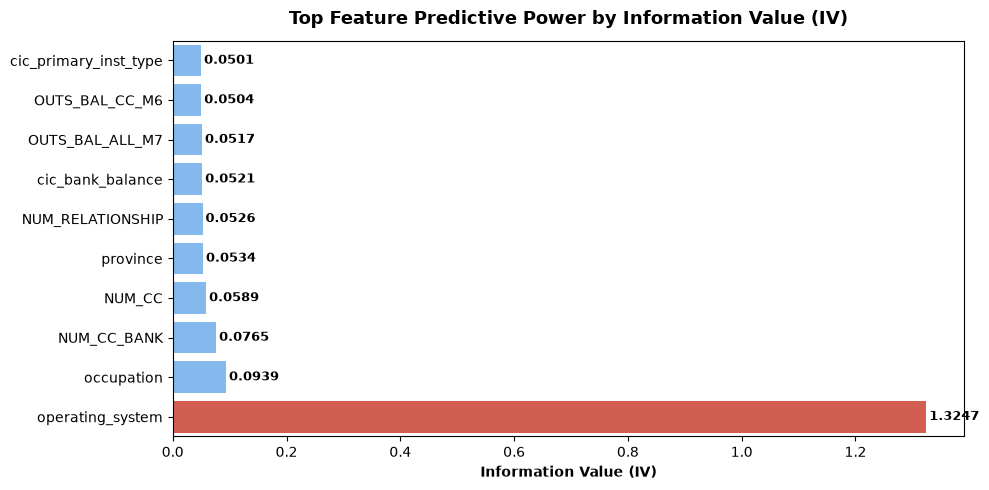

Generating WoE Profile for Top Predictors: 'operating_system' and 'occupation'


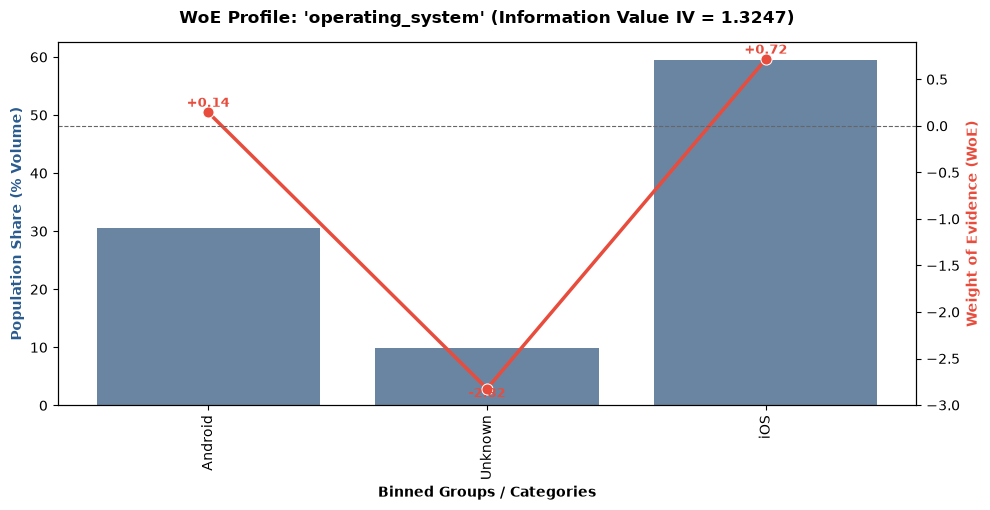

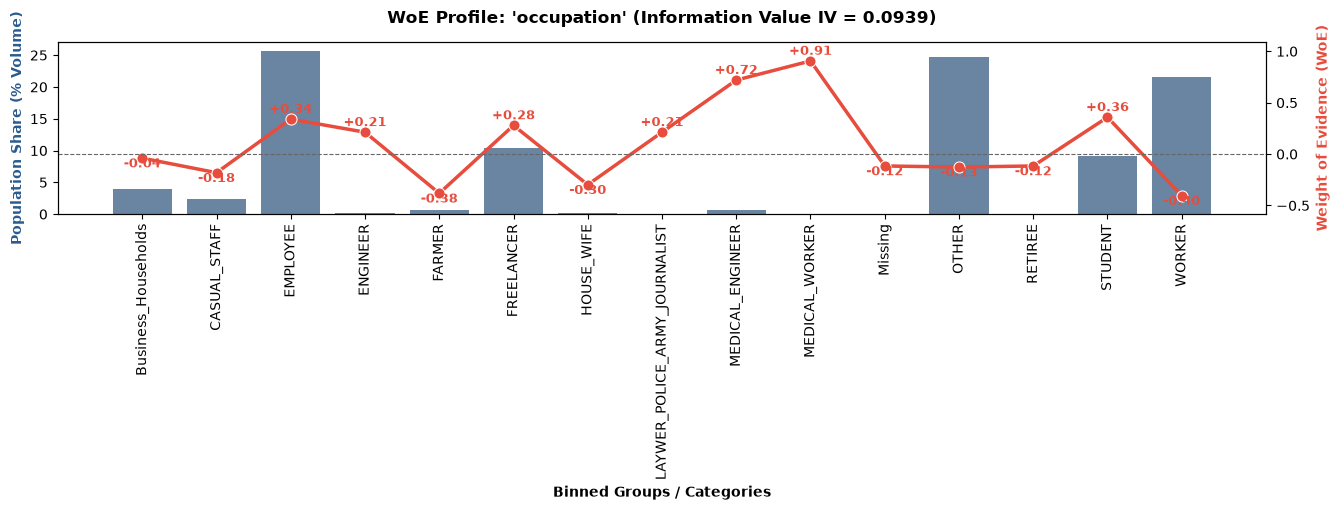

In [15]:
# ==============================================================================
# 13. Information Value (IV) Screening & Weight of Evidence (WoE) Analysis
# ==============================================================================
def calculate_information_value(data, feature, target, bins=5):
    """
    Computes Information Value (IV) and returns WoE table for a given feature.
    Industry Standard IV thresholds:
      - IV < 0.02: Useless / Unpredictive
      - 0.02 <= IV < 0.10: Weak predictive power
      - 0.10 <= IV < 0.30: Medium predictive power
      - IV >= 0.30: Strong predictive power (Key drivers)
    """
    if data[feature].nunique() <= 1:
        return 0.0, None
    
    # Quantile binning for continuous numeric features, categorical grouping for discrete/strings
    if pd.api.types.is_numeric_dtype(data[feature]) and data[feature].nunique() > 8:
        binned = pd.qcut(data[feature], q=bins, duplicates="drop")
    else:
        binned = data[feature].fillna("Missing").astype(str)
        
    cross = pd.crosstab(binned, data[target], margins=False)
    if cross.shape[1] < 2:
        return 0.0, None
        
    total_good = (data[target] == 0).sum()
    total_bad = (data[target] == 1).sum()
    
    if total_good == 0 or total_bad == 0:
        return 0.0, None
        
    good_dist = (cross[0] / total_good).replace(0, 0.0001)
    bad_dist = (cross[1] / total_bad).replace(0, 0.0001)
    
    woe = np.log(good_dist / bad_dist)
    iv = ((good_dist - bad_dist) * woe).sum()
    
    # Prepare summary table for WoE plotting
    vol_pct = (cross.sum(axis=1) / len(data)) * 100
    bad_rate_pct = (cross[1] / cross.sum(axis=1)) * 100
    
    woe_df = pd.DataFrame({
        "Bin": [str(x) for x in cross.index],
        "Volume_Pct": vol_pct.values,
        "Bad_Rate_Pct": bad_rate_pct.values,
        "WoE": woe.values
    })
    
    return iv, woe_df

# ------------------------------------------------------------------------------
# 1. Compute and Rank IV across all candidate features
# ------------------------------------------------------------------------------
iv_results = []
woe_tables = {}
ignore_cols = [target_col, "disbursement_date"]

for col in df.columns:
    if col not in ignore_cols and not any(k in col.lower() for k in ["id", "cif", "cust"]):
        try:
            iv_val, w_df = calculate_information_value(df, col, target_col)
            if not np.isnan(iv_val) and iv_val > 0:
                if iv_val >= 0.30:
                    power = "Strong (Key Predictor)"
                elif iv_val >= 0.10:
                    power = "Medium"
                elif iv_val >= 0.02:
                    power = "Weak"
                else:
                    power = "Unpredictive / Prunable"
                    
                iv_results.append({
                    "Feature": col,
                    "Information Value (IV)": round(iv_val, 4),
                    "Predictive Power": power
                })
                woe_tables[col] = w_df
        except Exception:
            continue

iv_df = pd.DataFrame(iv_results).sort_values("Information Value (IV)", ascending=False).reset_index(drop=True)

print("=" * 80)
print("TOP 15 FEATURES BY INFORMATION VALUE (IV) SCREENING")
print("=" * 80)
display(iv_df.head(15))
print("=" * 80 + "\n")


# ------------------------------------------------------------------------------
# 2. Plot Top IV Feature Rankings (Horizontal Bar Chart)
# ------------------------------------------------------------------------------
top_iv = iv_df.head(10).sort_values("Information Value (IV)", ascending=True)
plt.figure(figsize=(10, 5))
colors_iv = [RISK_COLOR if v >= 0.3 else (PRIMARY_COLOR if v >= 0.1 else "#74b9ff") for v in top_iv["Information Value (IV)"]]

sns.barplot(x="Information Value (IV)", y="Feature", data=top_iv, palette=colors_iv)
plt.title("Top Feature Predictive Power by Information Value (IV)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Information Value (IV)", fontsize=10, fontweight="bold")
plt.ylabel("")

for i, v in enumerate(top_iv["Information Value (IV)"]):
    plt.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 3. Helper Function: Plot Weight of Evidence (WoE) Line Chart (Fixed Axis Layout)
# ------------------------------------------------------------------------------
def plot_woe_profile(feature_name, rotation=90):
    """
    Plots standard Credit Scorecard Dual-Axis WoE Profile:
    - Left Axis (Bar): Population Volume Distribution (%) in Navy Blue
    - Right Axis (Line): Weight of Evidence (WoE) Trend in Coral Red
    - rotation: Angle for x-axis category labels (default 90 degrees with right alignment)
    """
    if feature_name not in woe_tables or woe_tables[feature_name] is None:
        print(f"WoE table for '{feature_name}' is not available.")
        return
        
    w_df = woe_tables[feature_name]
    iv_score = iv_df[iv_df["Feature"] == feature_name]["Information Value (IV)"].values[0]
    
    # Dynamically expand figure width if feature has many categories/bins
    fig_width = max(10, len(w_df) * 0.9)
    fig, ax1 = plt.subplots(figsize=(fig_width, 5.2))
    ax2 = ax1.twinx()
    
    # Left Axis: Application Volume Distribution (%)
    sns.barplot(data=w_df, x="Bin", y="Volume_Pct", ax=ax1, color=PRIMARY_COLOR, alpha=0.75)
    ax1.set_ylabel("Population Share (% Volume)", color=PRIMARY_COLOR, fontsize=10, fontweight="bold")
    ax1.set_xlabel("Binned Groups / Categories", fontsize=10, fontweight="bold")
    ax1.grid(False)
    
    # Rotate x-axis category labels and right-align to avoid overlapping text
    ax1.tick_params(axis="x", rotation=rotation)
    plt.setp(ax1.get_xticklabels(), ha="right" if rotation in [45, 30] else "center")
    
    # Right Axis: WoE Line Plot
    sns.lineplot(data=w_df, x="Bin", y="WoE", ax=ax2, color=RISK_COLOR, marker="o", linewidth=2.5, markersize=8)
    ax2.set_ylabel("Weight of Evidence (WoE)", color=RISK_COLOR, fontsize=10, fontweight="bold")
    ax2.axhline(0, color="#666666", linestyle="--", linewidth=0.8)
    
    # Dynamically set y-limits on WoE axis to ensure annotations have breathing room
    woe_min, woe_max = w_df["WoE"].min(), w_df["WoE"].max()
    ax2.set_ylim(woe_min - 0.18, woe_max + 0.18)
    
    # Annotate WoE values on markers
    for i, val in enumerate(w_df["WoE"]):
        offset = 0.06 if val >= 0 else -0.09
        ax2.annotate(f"{val:+.2f}", (i, val + offset), ha="center", color=RISK_COLOR, fontweight="bold", fontsize=9)
        
    plt.title(f"WoE Profile: '{feature_name}' (Information Value IV = {iv_score:.4f})", fontsize=12, fontweight="bold", pad=14)
    plt.tight_layout()
    plt.show()

# Example: Plot WoE Profile for top predictive features
if not iv_df.empty:
    top_feature_1 = iv_df.iloc[0]["Feature"]
    top_feature_2 = iv_df.iloc[1]["Feature"]
    
    print(f"Generating WoE Profile for Top Predictors: '{top_feature_1}' and '{top_feature_2}'")
    plot_woe_profile(top_feature_1)
    plot_woe_profile(top_feature_2)

## Key Takeaways & Preprocessing Action Plan:

1. **Leakage Elimination**: All post-disbursement performance proxies (e.g., `FPD10+`, other DPD targets) and arbitrary ID identifiers (`customer_id`, `contract_id`) were filtered out to prevent data leakage and overfitting.
2. **Age & Demographics**: Younger customer segments (`<22`, `22-28`) typically exhibit higher default volatility compared to mature age brackets (`36-45`).
3. **Income & Loan Terms**: Lower income quartiles and longer loan durations correspond to elevated risk profiles.
4. **CIC Bureau Signals**: Features like `cic_has_fin_loan`, `cic_primary_inst_type`, and `cic_inquiry_3m` provide strong risk divergence.
5. **Categorical Features**: `province` (`Hanoi`, `Danang`, `Saigon`, `Others`) and `operating_system` (`iOS`, `Android`, `Unknown`) should be one-hot encoded or target encoded.
6. **Missing Values**: CIC scores and credit limits have missing values for thin-file / new-to-credit customers. Missing indicators and median/zero imputation strategies should be set up in `src/components/preprocessor.py`.